# 🗽 NYC Food Deserts & Crime Analysis
## Scripting for Data Analysis — Final Project
### Philippe Louis Jr.

---

## Overview

Imagining New York City as having "food deserts" almost seems like an oxymoron in a place known for its large, unmatched diversity and multitude of highly rated restaurants. What makes an area a food desert is not only the quantity of the options but the quality. Yet, today there are still communities within all five boroughs that deal with food insecurities affecting quality of life for all that reside in it.

Instead of having quality grocery stores accessible to their respective community, many are forced to rely on the once-cheap but always convenient processed meats of bodega sandwiches and chips from the delis as their main source of nutrition — or be forced to travel to a neighbourhood over to the more expensive 'healthier' options that cater towards the wallets of 'transplants' who don't mind paying the difference for "organic" options.

**Thesis:** Food insecurity is a social determinant of crime. People denied access to a healthy environment cannot sustain a healthy lifestyle which will be reinforced through the analytical findings below.

---

## Data Sources
- **Google Places API** — food establishment listings (grocery stores, restaurants, fast food, and bodegas) by neighborhood ZIP code
- **NYC Open Data — NYPD Arrests** — arrest records with geographic coordinates, covering all five boroughs
- **NYC Open Data — Restaurant Inspections** — official NYC Health Department inspection grades per establishment
- **U.S. Census ACS 5-Year Estimates** — population, median household income, and poverty rates by ZIP code
- **MongoDB Atlas** — all raw and processed data stored and retrieved as JSON documents

---

## Neighborhoods Studied

27 neighborhoods across all five NYC boroughs were selected to represent a spectrum of income levels, food access conditions, and demographic profiles.

| Neighborhood | Borough | Classification |
|---|---|---|
| South Bronx | Bronx | 🏜️ Food Desert |
| Highbridge | Bronx | 🏜️ Food Desert |
| Belmont | Bronx | ✅ Non-Desert |
| Riverdale | Bronx | ✅ Non-Desert |
| East New York | Brooklyn | 🏜️ Food Desert |
| Bedford-Stuyvesant | Brooklyn | 🏜️ Food Desert |
| Crown Heights | Brooklyn | 🏜️ Food Desert |
| Coney Island | Brooklyn | 🏜️ Food Desert |
| Bensonhurst | Brooklyn | 🏜️ Food Desert |
| Sheepshead Bay | Brooklyn | 🏜️ Food Desert |
| Clinton Hill / Fort Greene | Brooklyn | 🏜️ Food Desert |
| Red Hook | Brooklyn | 🏜️ Food Desert |
| Park Slope | Brooklyn | 🏜️ Food Desert |
| Midwood | Brooklyn | ✅ Non-Desert |
| Washington Heights | Manhattan | 🏜️ Food Desert |
| Harlem | Manhattan | 🏜️ Food Desert |
| Chinatown / Lower East Side | Manhattan | 🏜️ Food Desert |
| Greenwich Village | Manhattan | 🏜️ Food Desert |
| Upper West Side | Manhattan | 🏜️ Food Desert |
| Astoria | Queens | 🏜️ Food Desert |
| Jamaica | Queens | 🏜️ Food Desert |
| Forest Hills | Queens | 🏜️ Food Desert |
| Kew Gardens | Queens | ✅ Non-Desert |
| Middle Village | Queens | ✅ Non-Desert |
| Far Rockaway | Queens | ✅ Non-Desert |
| St. George | Staten Island | 🏜️ Food Desert |
| Tottenville | Staten Island | ✅ Non-Desert |

---

> **Note on Methodology:** Neighborhoods are defined by ZIP code tabulation areas (ZCTAs) rather than informal boundaries, ensuring consistency with U.S. Census and NYC Open Data geographic keys. A neighborhood is classified as a food desert if its grocery-to-fast-food ratio falls below 1.0 — meaning fast food establishments outnumber grocery stores relative to population.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from pymongo import MongoClient
import certifi
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings("ignore")

# Load environment variables
load_dotenv()

# MongoDB connection
MONGO_URI = os.getenv("MONGO_URI")
DB_NAME = "fooddesert"

client = MongoClient(MONGO_URI, tlsCAFile=certifi.where())
db = client[DB_NAME]

# Load all collections
places_df = pd.DataFrame(list(db["places"].find())).drop(columns=["_id"], errors="ignore")
arrests_df = pd.DataFrame(list(db["arrests"].find())).drop(columns=["_id"], errors="ignore")
inspections_df = pd.DataFrame(list(db["inspections"].find())).drop(columns=["_id"], errors="ignore")
census_df = pd.DataFrame(list(db["census"].find())).drop(columns=["_id"], errors="ignore")
summary_df = pd.DataFrame(list(db["summary"].find())).drop(columns=["_id"], errors="ignore")

# Add borough mapping
borough_map = {
    "South Bronx": "Bronx",
    "Highbridge": "Bronx",
    "Belmont": "Bronx",
    "Riverdale": "Bronx",
    "East New York": "Brooklyn",
    "Bedford-Stuyvesant": "Brooklyn",
    "Crown Heights": "Brooklyn",
    "Coney Island": "Brooklyn",
    "Bensonhurst": "Brooklyn",
    "Sheepshead Bay": "Brooklyn",
    "Clinton Hill / Fort Greene": "Brooklyn",
    "Red Hook": "Brooklyn",
    "Park Slope": "Brooklyn",
    "Midwood": "Brooklyn",
    "Washington Heights": "Manhattan",
    "Harlem": "Manhattan",
    "Chinatown / Lower East Side": "Manhattan",
    "Greenwich Village": "Manhattan",
    "Upper West Side": "Manhattan",
    "Astoria": "Queens",
    "Jamaica": "Queens",
    "Forest Hills": "Queens",
    "Kew Gardens": "Queens",
    "Middle Village": "Queens",
    "Far Rockaway": "Queens",
    "St. George": "Staten Island",
    "Tottenville": "Staten Island",
}
summary_df["borough"] = summary_df["neighborhood"].map(borough_map)

# Verify
print(f"Places:      {len(places_df):,} records")
print(f"Arrests:     {len(arrests_df):,} records")
print(f"Inspections: {len(inspections_df):,} records")
print(f"Census:      {len(census_df):,} records")
print(f"Summary:     {len(summary_df):,} neighborhood records")
print(f"\n✅ All collections loaded successfully")

Places:      2,315 records
Arrests:     147,507 records
Inspections: 65,959 records
Census:      38 records
Summary:     27 neighborhood records

✅ All collections loaded successfully


---
## Data Collection

Data was collected using four methods:

1. **Google Places API** — queried by ZIP code for grocery stores, restaurants, fast food chains, and bodegas across 38 ZIP codes covering 27 NYC neighborhoods spanning all five boroughs. All raw JSON responses were stored directly into MongoDB Atlas as-is before any cleaning or transformation.

2. **NYC Open Data Socrata API** — two datasets were collected:
   - **NYPD Arrests Dataset** — queried by geographic bounding box coordinates since the dataset contains no ZIP code field. Coordinates are stored as strings in the API requiring string-based comparisons rather than numeric queries.
   - **NYC Health Department Restaurant Inspections** — queried directly by ZIP code, returning inspection grades, violation descriptions, and establishment details.

3. **U.S. Census Bureau ACS 5-Year Estimates API** — queried by ZIP code tabulation area (ZCTA) for total population, median household income, and poverty count. Data reflects 2023 5-year estimates providing the most statistically reliable neighborhood-level demographic figures available.

4. **NYC GeoJSON Boundary Data** — ZIP code boundary polygons were fetched from a public GeoJSON source to enable neighborhood border rendering on the interactive Folium map.

All raw data was stored directly into **MongoDB Atlas** as JSON documents before any cleaning or transformation, preserving the original structure for reproducibility. MongoDB was chosen specifically because Google Places and Socrata both return nested JSON — storing raw responses without flattening allowed the full data structure to be preserved and re-queried during the cleaning phase.

In [13]:
# Summary of raw data collected per neighborhood
raw_summary = places_df.groupby(["neighborhood", "search_type"]).size().unstack(fill_value=0)

# Reorder columns nicely
col_order = [c for c in ["grocery store", "bodega", "fast food", "restaurant"] if c in raw_summary.columns]
raw_summary = raw_summary[col_order]
raw_summary.columns = ["Grocery Stores", "Bodegas", "Fast Food", "Restaurants"]
raw_summary["Total Places"] = raw_summary.sum(axis=1)

print(" Google Places Data Collected by Neighborhood")
print("=" * 70)
print(raw_summary.to_string())

print("\n\n🚔 Arrest Records Collected by Neighborhood")
print("=" * 70)
arrest_counts = arrests_df.groupby("neighborhood").size().reset_index(name="Total Arrests")
arrest_counts = arrest_counts.sort_values("Total Arrests", ascending=False)
print(arrest_counts.to_string(index=False))

print("\n\n Inspection Records Collected by Neighborhood")
print("=" * 70)
inspection_counts = inspections_df.groupby("neighborhood").size().reset_index(name="Total Inspections")
inspection_counts = inspection_counts.sort_values("Total Inspections", ascending=False)
print(inspection_counts.to_string(index=False))

print("\n\n👥 Census Data Collected by Neighborhood")
print("=" * 70)
census_summary = census_df.groupby("neighborhood").agg(
    total_population=("population", "sum"),
    avg_income=("median_income", "mean")
).reset_index()
census_summary["avg_income"] = census_summary["avg_income"].apply(lambda x: f"${x:,.0f}")
census_summary["total_population"] = census_summary["total_population"].apply(lambda x: f"{x:,}")
census_summary = census_summary.sort_values("neighborhood")
print(census_summary.to_string(index=False))

 Google Places Data Collected by Neighborhood
                             Grocery Stores  Bodegas  Fast Food  Restaurants  Total Places
neighborhood                                                                              
Astoria                                  26       26         31           32           115
Bedford-Stuyvesant                       18       15         32           31            96
Belmont                                  19       19         19           19            76
Bensonhurst                              19        9         20           19            67
Chinatown / Lower East Side              17       20         20           20            77
Clinton Hill / Fort Greene               25       16         34           35           110
Coney Island                             19        3         20           15            57
Crown Heights                            15        9         18           14            56
East New York                            34 

---
## Data Cleaning & Merging

Raw data was pulled from MongoDB Atlas into pandas DataFrames and processed 
through the following pipeline:

**Places (Google Places API)**
- Deduplicated on `place_id` to remove establishments that appeared across 
  multiple ZIP code queries for the same neighborhood
- Converted `rating`, `user_ratings_total`, and `price_level` fields from 
  mixed types to numeric
- Aggregated by neighborhood and search type to compute counts, average ratings, 
  and average price level per area

**Arrests (NYPD)**
- Deduplicated on `arrest_key` to remove duplicate records introduced by 
  overlapping bounding boxes between neighboring ZIP codes
- Normalized by population to compute **arrests per 10,000 residents** — 
  raw arrest counts alone are misleading given the significant population 
  differences across neighborhoods
- Broken down by offense type to enable food desert vs non-desert crime 
  profile comparison

**Inspections (NYC Health Department)**
- Deduplicated on `camis` (unique restaurant ID), keeping only the most 
  recent inspection per establishment to reflect current health grade status
- Aggregated grade counts (A, B, C) per neighborhood and computed 
  percentage of Grade A inspections as a food quality proxy

**Census (ACS 5-Year Estimates)**
- Aggregated across ZIP codes within each neighborhood to compute total 
  population, average median household income, and overall poverty rate
- Poverty rate computed as total poverty count divided by total population 
  per neighborhood

**Merging & Normalization**
- All four datasets were merged on neighborhood name into a single master 
  summary DataFrame
- Population-normalized metrics were computed after merging:
  - Grocery stores, bodegas, fast food, and restaurants per 10,000 residents
  - Grocery-to-fast-food ratio computed using per-10k values rather than 
    raw counts to fairly compare neighborhoods of different sizes
- The final summary was written back to MongoDB as a `summary` collection, 
  making it accessible for both the analysis scripts and the Jupyter notebook

**Food Desert Classification**
- A neighborhood is classified as a food desert if its population-normalized 
  grocery-to-fast-food ratio falls below 1.0 — meaning fast food establishments 
  outnumber grocery stores per capita

In [15]:
# Master summary table
display_cols = {
    "neighborhood": "Neighborhood",
    "borough": "Borough",
    "total_population": "Population",
    "avg_median_income": "Avg Income ($)",
    "poverty_rate": "Poverty Rate (%)",
    "grocery store_count": "Groceries",
    "bodega_count": "Bodegas",
    "fast food_count": "Fast Food",
    "grocery_to_fastfood_ratio": "Grocery/FastFood Ratio",
    "avg_google_rating": "Avg Google Rating",
    "total_arrests": "Total Arrests",
    "arrests_per_10k": "Arrests per 10k",
    "pct_grade_A": "% Grade A",
    "is_food_desert": "Food Desert?"
}

display_df = summary_df[[c for c in display_cols.keys() if c in summary_df.columns]].rename(columns=display_cols)
display_df["Avg Income ($)"] = display_df["Avg Income ($)"].apply(lambda x: f"${x:,.0f}")
display_df["Population"] = display_df["Population"].apply(lambda x: f"{x:,.0f}")
display_df["Food Desert?"] = display_df["Food Desert?"].apply(lambda x: "🏜️ Yes" if x else "✅ No")
display_df = display_df.sort_values("Grocery/FastFood Ratio", ascending=False)

display_df

,Neighborhood,Borough,Population,Avg Income ($),Poverty Rate (%),Groceries,Bodegas,Fast Food,Grocery/FastFood Ratio,Avg Google Rating,Total Arrests,Arrests per 10k,% Grade A,Food Desert?
2,Belmont,Bronx,"79,375","$44,911",33.8,19,19,19,1.00,4.209211,3439,433.3,90.9,✅ No
24,Tottenville,Staten Island,"14,821","$138,807",2.7,20,20,20,1.00,4.315385,557,375.8,87.0,✅ No
9,Far Rockaway,Queens,"68,704","$57,027",20.2,19,14,19,1.00,4.205970,2224,323.7,85.7,✅ No
20,Riverdale,Bronx,"23,400","$108,738",5.4,17,17,17,1.00,4.305634,1023,437.2,90.0,✅ No
3,Bensonhurst,Brooklyn,"88,994","$64,286",18.7,19,9,20,0.95,4.143284,2142,240.7,92.6,🏜️ Yes
6,Coney Island,Brooklyn,"48,469","$41,449",27.6,19,3,20,0.95,4.142105,2290,472.5,93.7,🏜️ Yes
17,Midwood,Brooklyn,"88,252","$69,522",19.0,19,13,20,0.95,4.364179,3021,342.3,94.4,🏜️ Yes
16,Middle Village,Queens,"37,378","$92,509",7.2,18,19,19,0.95,4.295652,1194,319.4,96.6,🏜️ Yes
14,Jamaica,Queens,"101,507","$73,286",13.9,30,15,32,0.94,4.228037,5615,553.2,93.9,🏜️ Yes
8,East New York,Brooklyn,"200,346","$57,704",23.2,34,29,37,0.92,4.142963,8878,443.1,94.7,🏜️ Yes


---
## Analysis





### Q1: Which NYC neighborhoods qualify as food deserts?

A neighborhood is classified as a food desert if its population-normalized 
grocery-to-fast-food ratio falls below 1.0 — meaning fast food establishments 
outnumber grocery stores per 10,000 residents. Of the 27 neighborhoods studied, 
**23 qualify as food deserts**, challenging the assumption that NYC's density and 
diversity automatically translate to food access. The worst affected are 
concentrated in the Bronx and parts of Brooklyn, where fast food outlets 
outnumber grocery stores by nearly two to one per capita. Adding bodega data 
as a fourth search type revealed a critical nuance — South Bronx has more 
bodegas than grocery stores, confirming that convenience stores are substituting 
for proper supermarket access. While bodegas provide some food options they 
primarily stock processed and packaged goods rather than fresh produce, 
reinforcing food insecurity rather than solving it.

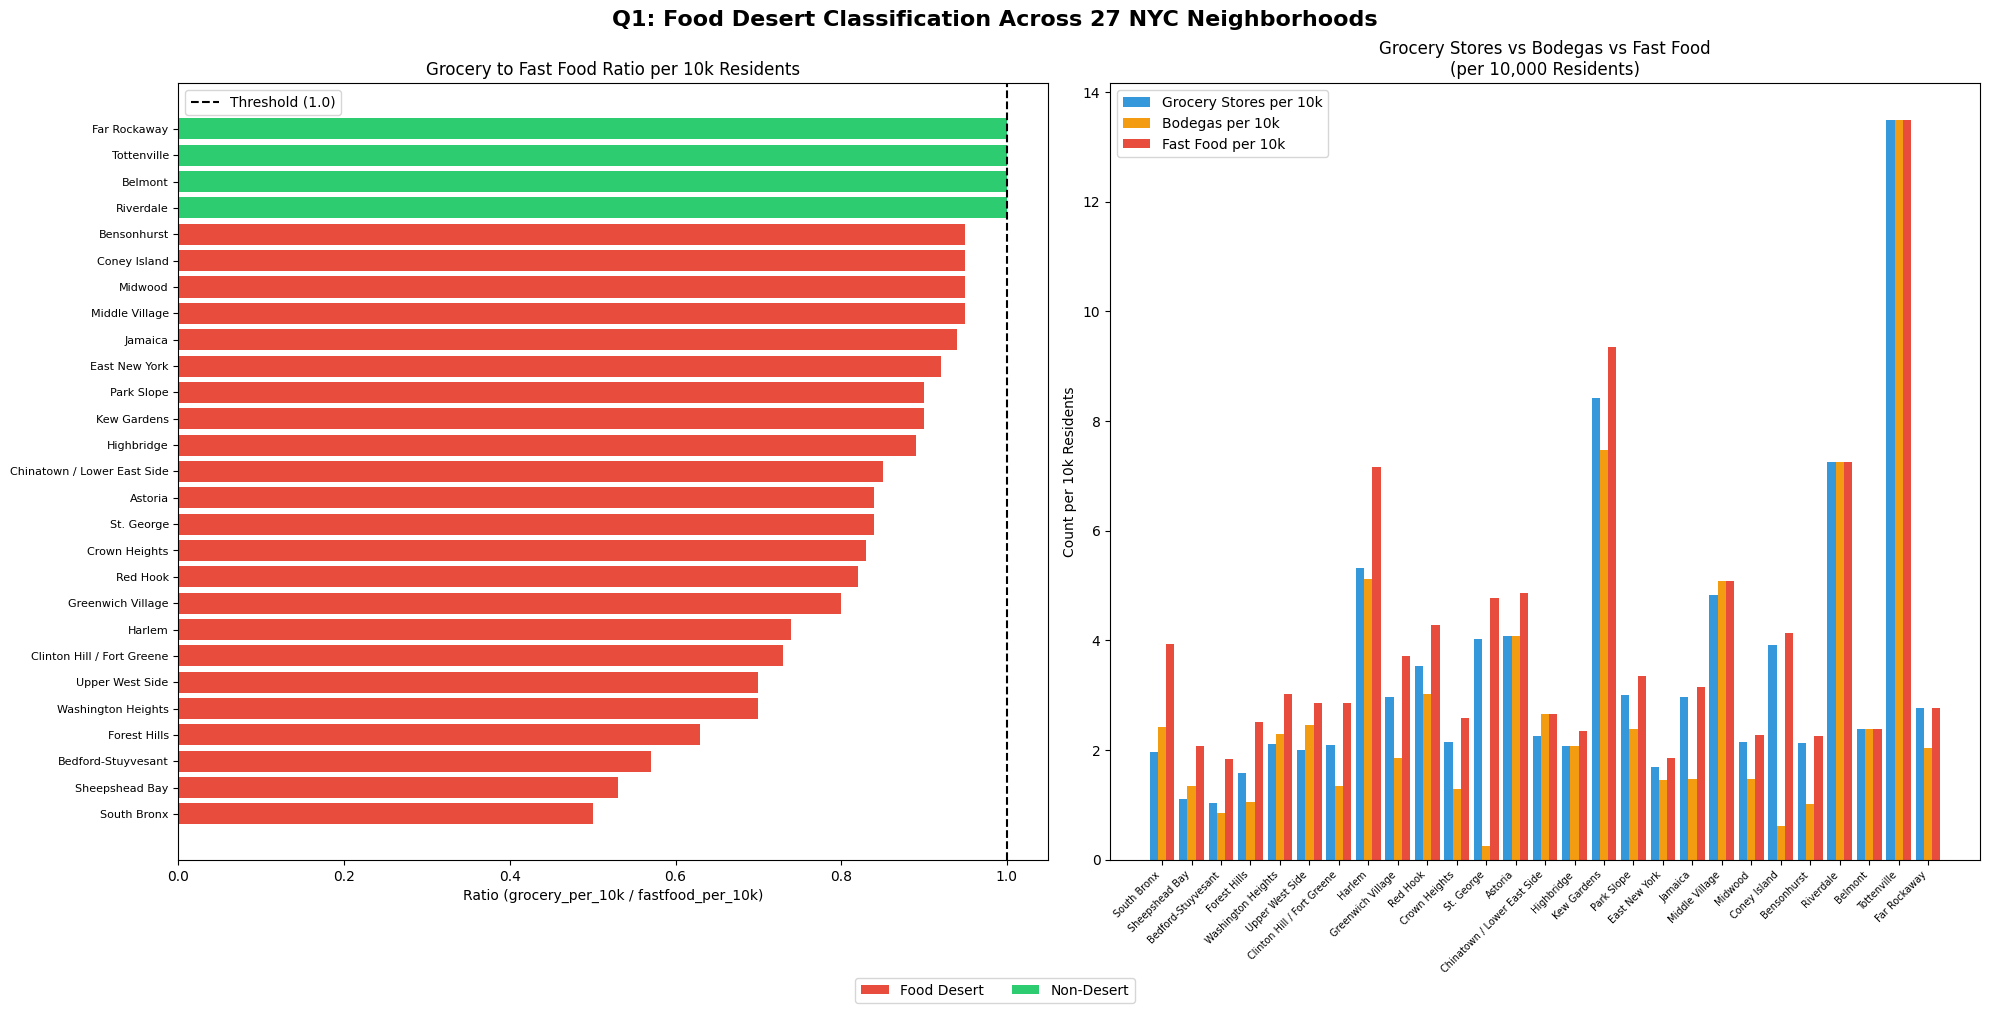

In [16]:
# Q1 - Food Desert Classification Chart
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle("Q1: Food Desert Classification Across 27 NYC Neighborhoods", 
             fontsize=16, fontweight="bold")

q1_df = summary_df.sort_values("grocery_to_fastfood_ratio")
colors = ["#e74c3c" if x else "#2ecc71" for x in q1_df["is_food_desert"]]

# Chart 1 - Population normalized grocery to fast food ratio
axes[0].barh(q1_df["neighborhood"], q1_df["grocery_to_fastfood_ratio"], color=colors)
axes[0].axvline(x=1.0, color="black", linestyle="--", linewidth=1.5, label="Threshold (1.0)")
axes[0].set_title("Grocery to Fast Food Ratio per 10k Residents")
axes[0].set_xlabel("Ratio (grocery_per_10k / fastfood_per_10k)")
axes[0].legend()
axes[0].tick_params(axis="y", labelsize=8)

# Chart 2 - Grocery vs Fast Food vs Bodega per 10k
q1_sorted = summary_df.sort_values("grocery_to_fastfood_ratio")
x = range(len(q1_sorted))
width = 0.28

axes[1].bar([i - width for i in x], q1_sorted["grocery_per_10k"], 
            width, label="Grocery Stores per 10k", color="#3498db")
axes[1].bar([i for i in x], q1_sorted["bodega_per_10k"], 
            width, label="Bodegas per 10k", color="#f39c12")
axes[1].bar([i + width for i in x], q1_sorted["fastfood_per_10k"], 
            width, label="Fast Food per 10k", color="#e74c3c")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(q1_sorted["neighborhood"], rotation=45, ha="right", fontsize=7)
axes[1].set_title("Grocery Stores vs Bodegas vs Fast Food\n(per 10,000 Residents)")
axes[1].set_ylabel("Count per 10k Residents")
axes[1].legend()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#e74c3c", label="Food Desert"),
                   Patch(facecolor="#2ecc71", label="Non-Desert")]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig("q1_food_desert_classification.png", dpi=150, bbox_inches="tight")
plt.show()


### Q2: Is there a correlation between food desert classification and overall crime rate?

Food desert neighborhoods average **505.6 arrests per 10,000 residents** compared 
to **392.5 for non-food deserts** — a 1.3x gap that holds after controlling for 
population size. South Bronx is the starkest example at 1,379 per 10,000, more 
than 11x Sheepshead Bay's 125, the lowest in the dataset. The relationship is not 
perfectly linear however — Greenwich Village is a food desert with a $153,750 
median income whose high arrest rate of 1,163 per 10,000 reflects its nightlife 
scene, student population, tourism, and homeless concentration rather than poverty 
or food insecurity directly. This serves as an important reminder that **food 
insecurity and crime share common root causes in poverty and systemic inequality** 
rather than one directly causing the other.

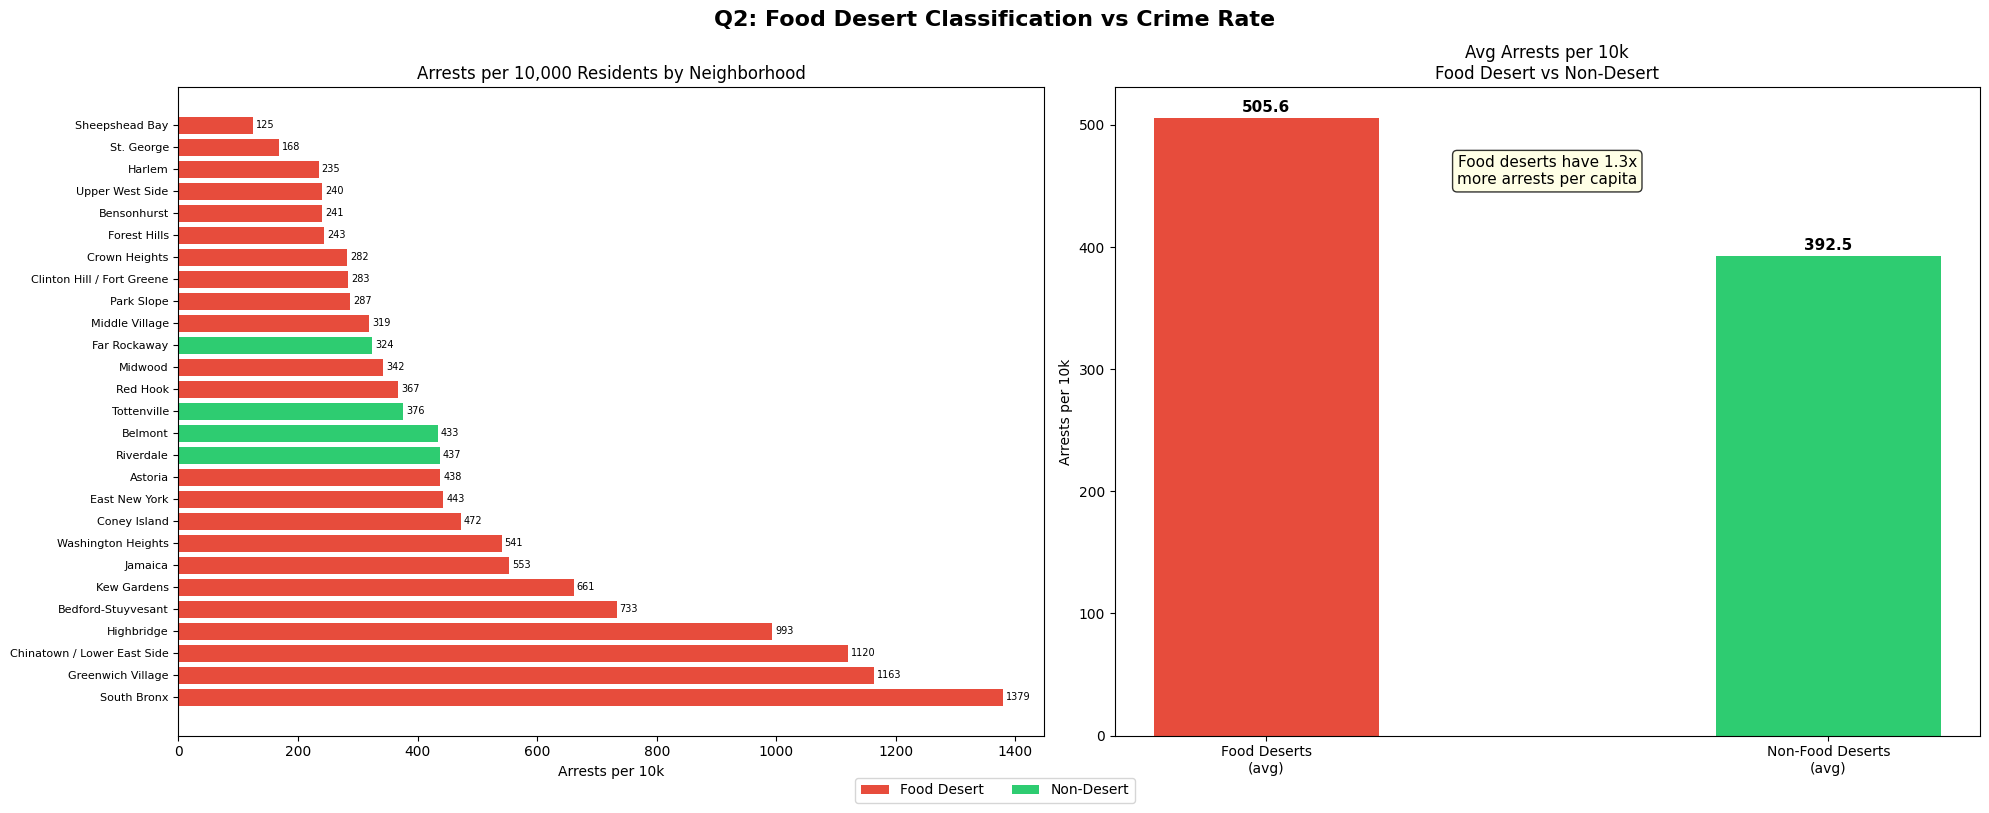

✅ Chart saved


In [5]:
# Q2 - Crime Rate Comparison
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Q2: Food Desert Classification vs Crime Rate", fontsize=16, fontweight="bold")

q2_df = summary_df.sort_values("arrests_per_10k", ascending=False)
colors = ["#e74c3c" if x else "#2ecc71" for x in q2_df["is_food_desert"]]

# Chart 1 - Arrests per 10k by neighborhood
axes[0].barh(q2_df["neighborhood"], q2_df["arrests_per_10k"], color=colors)
axes[0].set_title("Arrests per 10,000 Residents by Neighborhood")
axes[0].set_xlabel("Arrests per 10k")
axes[0].tick_params(axis="y", labelsize=8)

for i, val in enumerate(q2_df["arrests_per_10k"]):
    axes[0].text(val + 5, i, f"{val:.0f}", va="center", fontsize=7)

# Chart 2 - Food Desert vs Non Desert average
desert_avg = summary_df[summary_df["is_food_desert"] == True]["arrests_per_10k"].mean()
non_desert_avg = summary_df[summary_df["is_food_desert"] == False]["arrests_per_10k"].mean()

categories = ["Food Deserts\n(avg)", "Non-Food Deserts\n(avg)"]
values = [desert_avg, non_desert_avg]
bar_colors = ["#e74c3c", "#2ecc71"]

bars = axes[1].bar(categories, values, color=bar_colors, width=0.4)
axes[1].set_title("Avg Arrests per 10k\nFood Desert vs Non-Desert")
axes[1].set_ylabel("Arrests per 10k")

for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 5,
                f"{val:.1f}", ha="center", fontsize=11, fontweight="bold")

axes[1].text(0.5, 0.85, f"Food deserts have {desert_avg/non_desert_avg:.1f}x\nmore arrests per capita",
            transform=axes[1].transAxes, ha="center", fontsize=11,
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#e74c3c", label="Food Desert"),
                   Patch(facecolor="#2ecc71", label="Non-Desert")]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig("q2_crime_rate.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")

### Q3: How does the fast food to grocery ratio change as median income decreases?

The expectation was that as median income increases the grocery-to-fast-food ratio 
should improve — the data only partially supports this. The correlation is just 
**0.02** city-wide, meaning income barely predicts food access at the neighborhood 
level. Low income Bronx neighborhoods like South Bronx (avg income 33k) sit at the 
bottom of the ratio scale as expected, but wealthy neighborhoods like Greenwich 
Village (avg income 153k) and Upper West Side (avg income 170k) also fall below 
the 1.0 threshold. The correlation between income and arrests per 10,000 residents 
is stronger at **-0.24**, meaning higher income offers modest protection against 
crime but is far from deterministic. Income alone does not determine food access 
in NYC — neighborhood density, land use history, zoning, and cultural character 
all shape the food environment independently of wealth, making food desert 
intervention a structural and policy challenge, not simply an economic one.

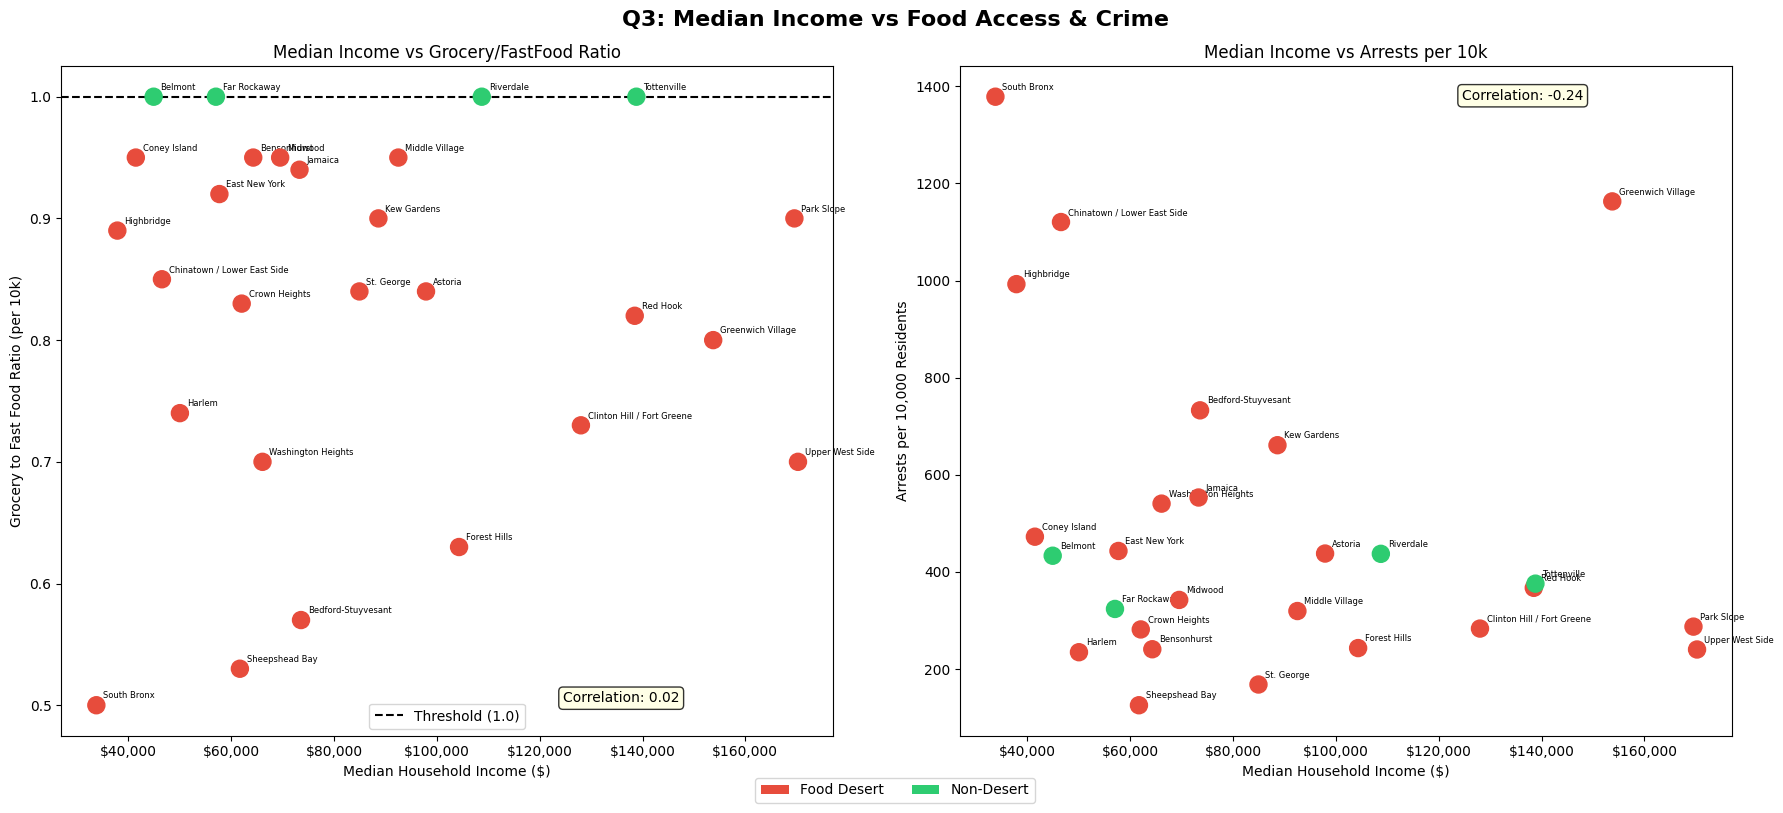

Correlation — Income vs Grocery/FastFood Ratio: 0.02
Correlation — Income vs Arrests per 10k:        -0.24


In [18]:
# Q3 - Income vs Food Access & Crime
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("Q3: Median Income vs Food Access & Crime", fontsize=16, fontweight="bold")

colors = ["#e74c3c" if x else "#2ecc71" for x in summary_df["is_food_desert"]]

# Chart 1 - Income vs Grocery/FastFood Ratio
axes[0].scatter(summary_df["avg_median_income"], summary_df["grocery_to_fastfood_ratio"],
                c=colors, s=150, zorder=5)
axes[0].axhline(y=1.0, color="black", linestyle="--", linewidth=1.5, label="Threshold (1.0)")

for _, row in summary_df.iterrows():
    axes[0].annotate(row["neighborhood"],
                    (row["avg_median_income"], row["grocery_to_fastfood_ratio"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=6)

axes[0].set_title("Median Income vs Grocery/FastFood Ratio")
axes[0].set_xlabel("Median Household Income ($)")
axes[0].set_ylabel("Grocery to Fast Food Ratio (per 10k)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].legend()

# Chart 2 - Income vs Arrests per 10k
axes[1].scatter(summary_df["avg_median_income"], summary_df["arrests_per_10k"],
                c=colors, s=150, zorder=5)

for _, row in summary_df.iterrows():
    axes[1].annotate(row["neighborhood"],
                    (row["avg_median_income"], row["arrests_per_10k"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=6)

axes[1].set_title("Median Income vs Arrests per 10k")
axes[1].set_xlabel("Median Household Income ($)")
axes[1].set_ylabel("Arrests per 10,000 Residents")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

corr_ratio = summary_df["avg_median_income"].corr(summary_df["grocery_to_fastfood_ratio"])
corr_crime = summary_df["avg_median_income"].corr(summary_df["arrests_per_10k"])

axes[0].text(0.65, 0.05, f"Correlation: {corr_ratio:.2f}",
            transform=axes[0].transAxes, fontsize=10,
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

axes[1].text(0.65, 0.95, f"Correlation: {corr_crime:.2f}",
            transform=axes[1].transAxes, fontsize=10,
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#e74c3c", label="Food Desert"),
                   Patch(facecolor="#2ecc71", label="Non-Desert")]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig("q3_income_vs_food_access.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Correlation — Income vs Grocery/FastFood Ratio: {corr_ratio:.2f}")
print(f"Correlation — Income vs Arrests per 10k:        {corr_crime:.2f}")

---
### Q4: How do food environment conditions compare across boroughs?

Aggregating neighborhoods by borough reveals clear patterns across all five 
boroughs. The Bronx stands out most starkly — highest average arrest rate, 
lowest average median income, and highest average poverty rate of all five 
boroughs. South Bronx and Highbridge together pull the Bronx averages to 
extremes that no other borough approaches. Brooklyn presents the widest 
internal range of any borough in this study, containing some of the most 
distressed neighborhoods (East New York, Bedford-Stuyvesant, Crown Heights) 
alongside some of the wealthiest (Park Slope, Red Hook, Clinton Hill / Fort 
Greene) — its borough-level averages mask the severity of conditions in its 
underserved eastern neighborhoods. Manhattan tells the most striking story: 
it is the wealthiest borough by average income yet contains multiple food 
deserts, demonstrating that food insecurity in NYC is not confined to 
low-income boroughs. Queens shows the most variation by income tier, with 
Jamaica and Far Rockaway sitting at opposite ends of the food access spectrum 
from Forest Hills and Kew Gardens. Staten Island, represented by St. George 
and Tottenville, shows the most suburban food environment profile — higher 
grocery density per capita and the lowest arrest rates of any borough in 
the study.



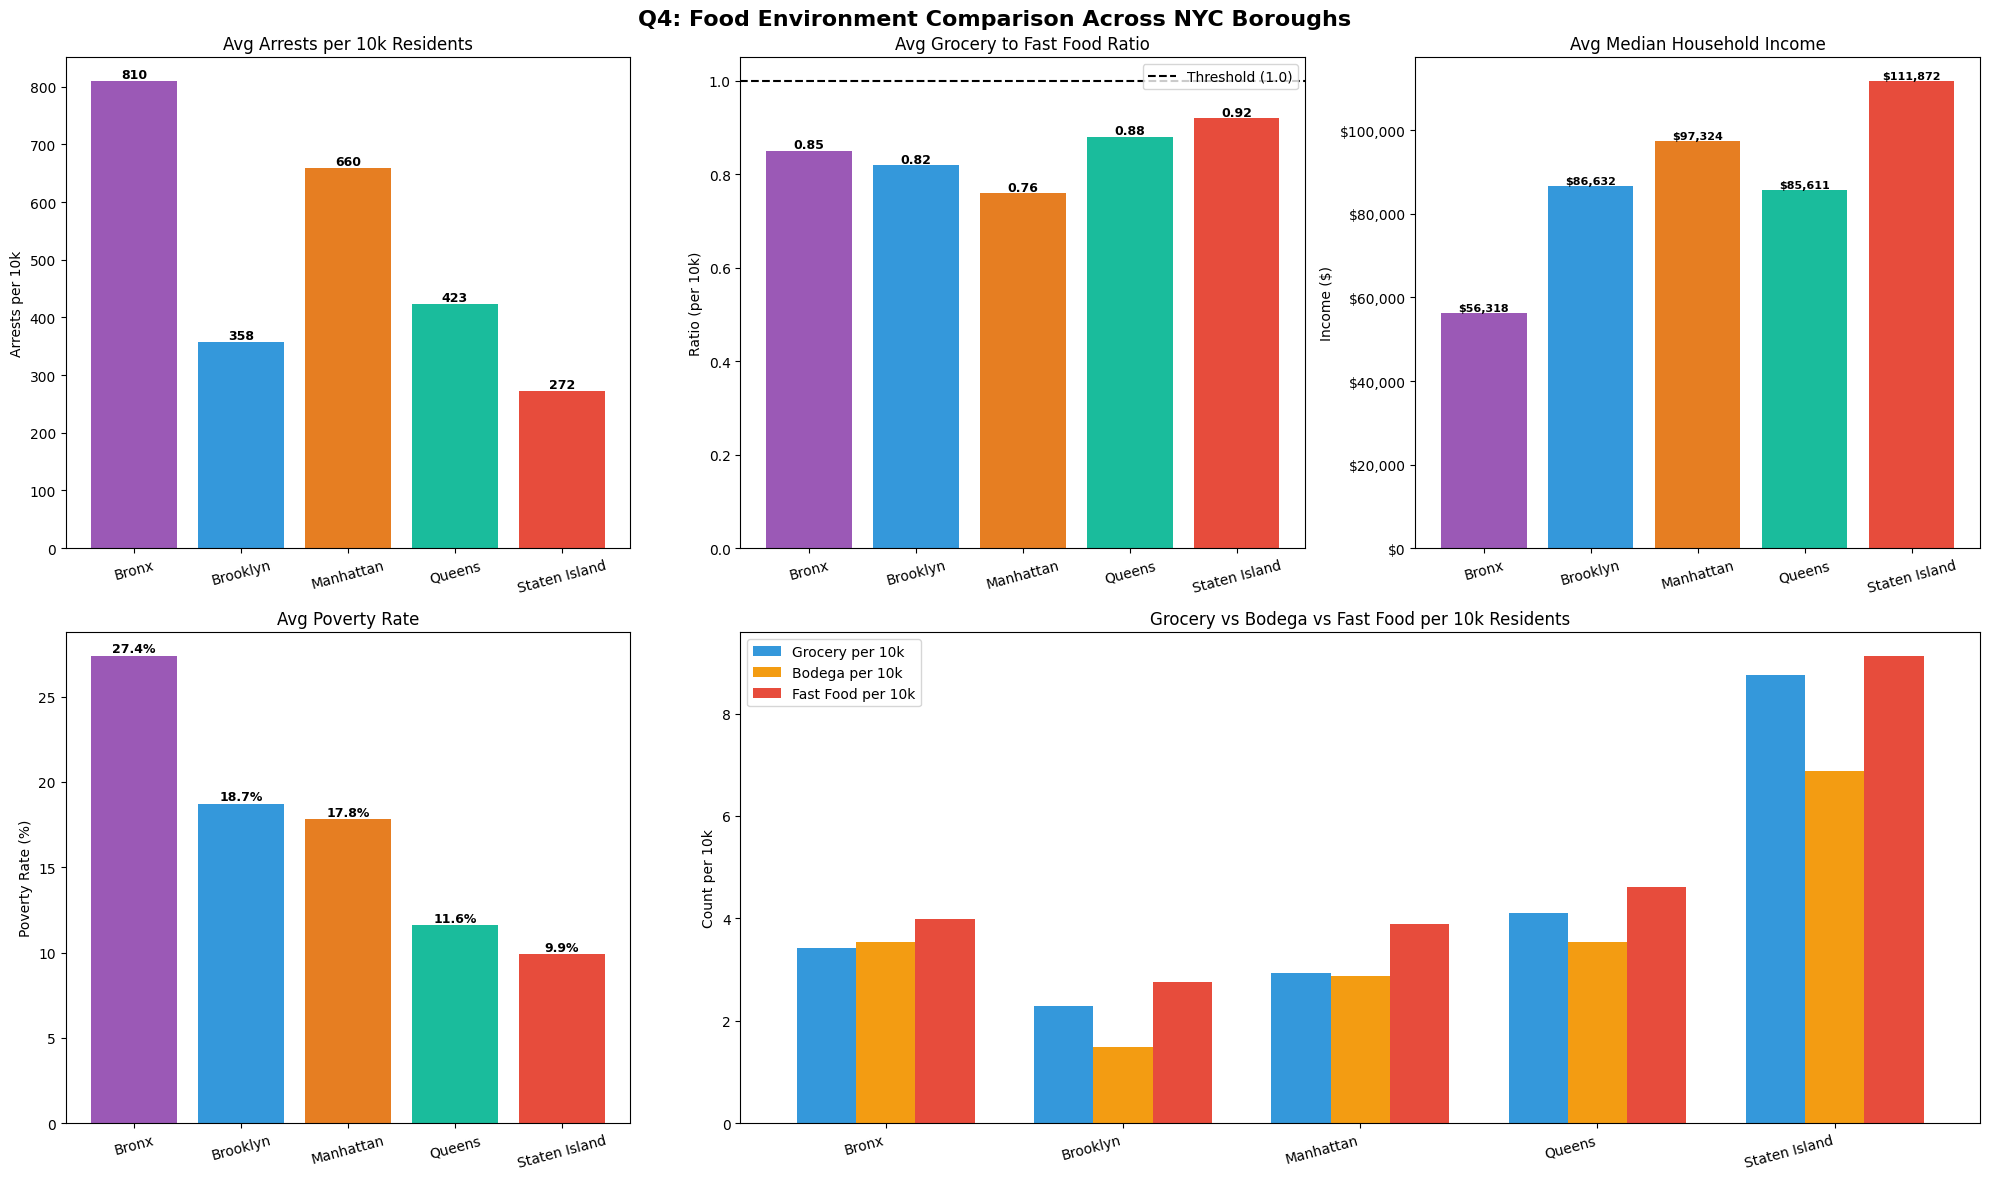

In [19]:
# Q4 - Borough Comparison
borough_order = ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]
borough_colors = {
    "Bronx": "#9b59b6",
    "Brooklyn": "#3498db", 
    "Manhattan": "#e67e22",
    "Queens": "#1abc9c",
    "Staten Island": "#e74c3c"
}

q5_df = summary_df.groupby("borough").agg(
    avg_grocery_ratio=("grocery_to_fastfood_ratio", "mean"),
    avg_grocery_per_10k=("grocery_per_10k", "mean"),
    avg_fastfood_per_10k=("fastfood_per_10k", "mean"),
    avg_bodega_per_10k=("bodega_per_10k", "mean"),
    avg_arrests_per_10k=("arrests_per_10k", "mean"),
    avg_income=("avg_median_income", "mean"),
    avg_poverty_rate=("poverty_rate", "mean"),
).reset_index().round(2)

q5_df["borough"] = pd.Categorical(q5_df["borough"], categories=borough_order, ordered=True)
q5_df = q5_df.sort_values("borough")
colors = [borough_colors[b] for b in q5_df["borough"]]

fig = plt.figure(figsize=(20, 12))
fig.suptitle("Q4: Food Environment Comparison Across NYC Boroughs",
             fontsize=16, fontweight="bold")

ax1 = fig.add_subplot(2, 3, 1)
ax2 = fig.add_subplot(2, 3, 2)
ax3 = fig.add_subplot(2, 3, 3)
ax4 = fig.add_subplot(2, 3, 4)
ax5 = fig.add_subplot(2, 3, (5, 6))

# Chart 1 - Avg arrests per 10k
bars = ax1.bar(q5_df["borough"], q5_df["avg_arrests_per_10k"], color=colors)
ax1.set_title("Avg Arrests per 10k Residents")
ax1.set_ylabel("Arrests per 10k")
ax1.tick_params(axis="x", rotation=15)
for bar, val in zip(bars, q5_df["avg_arrests_per_10k"]):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 5,
             f"{val:.0f}", ha="center", fontsize=9, fontweight="bold")

# Chart 2 - Avg grocery ratio
bars = ax2.bar(q5_df["borough"], q5_df["avg_grocery_ratio"], color=colors)
ax2.axhline(y=1.0, color="black", linestyle="--", linewidth=1.5, label="Threshold (1.0)")
ax2.set_title("Avg Grocery to Fast Food Ratio")
ax2.set_ylabel("Ratio (per 10k)")
ax2.tick_params(axis="x", rotation=15)
ax2.legend()
for bar, val in zip(bars, q5_df["avg_grocery_ratio"]):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.005,
             f"{val:.2f}", ha="center", fontsize=9, fontweight="bold")

# Chart 3 - Avg median income
bars = ax3.bar(q5_df["borough"], q5_df["avg_income"], color=colors)
ax3.set_title("Avg Median Household Income")
ax3.set_ylabel("Income ($)")
ax3.tick_params(axis="x", rotation=15)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for bar, val in zip(bars, q5_df["avg_income"]):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 500,
             f"${val:,.0f}", ha="center", fontsize=8, fontweight="bold")

# Chart 4 - Avg poverty rate
bars = ax4.bar(q5_df["borough"], q5_df["avg_poverty_rate"], color=colors)
ax4.set_title("Avg Poverty Rate")
ax4.set_ylabel("Poverty Rate (%)")
ax4.tick_params(axis="x", rotation=15)
for bar, val in zip(bars, q5_df["avg_poverty_rate"]):
    ax4.text(bar.get_x() + bar.get_width()/2, val + 0.2,
             f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")

# Chart 5 - Grocery vs Bodega vs Fast Food per 10k
x = range(len(q5_df))
width = 0.25
ax5.bar([i - width for i in x], q5_df["avg_grocery_per_10k"],
        width, label="Grocery per 10k", color="#3498db")
ax5.bar([i for i in x], q5_df["avg_bodega_per_10k"],
        width, label="Bodega per 10k", color="#f39c12")
ax5.bar([i + width for i in x], q5_df["avg_fastfood_per_10k"],
        width, label="Fast Food per 10k", color="#e74c3c")
ax5.set_xticks(list(x))
ax5.set_xticklabels(q5_df["borough"], rotation=15, ha="right")
ax5.set_title("Grocery vs Bodega vs Fast Food per 10k Residents")
ax5.set_ylabel("Count per 10k")
ax5.legend()

plt.tight_layout()
plt.savefig("q4_borough_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Q5: How do food environment conditions compare across boroughs?

The normalized metrics chart places all five boroughs on the same scale with 
1.0 representing the highest value in the dataset. The Bronx scores highest in 
both arrests per 10k and poverty rate while its income bar is the lowest of all 
five boroughs — confirming it bears the heaviest concentration of compounding 
disadvantages in this study. Manhattan has the second highest arrest rate driven 
largely by Greenwich Village and Chinatown / Lower East Side, yet its income bar 
is relatively high — a direct reflection of stark wealth inequality between its 
northern and southern neighborhoods. Queens presents the most balanced profile 
of any borough with moderate arrests, moderate poverty, and the highest grocery 
ratio score, reflecting how wealthy neighborhoods like Forest Hills and Kew 
Gardens offset underserved areas like Jamaica and Far Rockaway. Brooklyn sits 
in the middle across all four metrics, masking enormous internal variation between 
its wealthy brownstone neighborhoods and its underserved eastern communities. 
Staten Island tells the clearest suburban story — lowest arrest rate, lowest 
poverty rate, and highest median income and grocery ratio of all five boroughs, 
painting a picture of food access that looks fundamentally different from the 
rest of NYC.

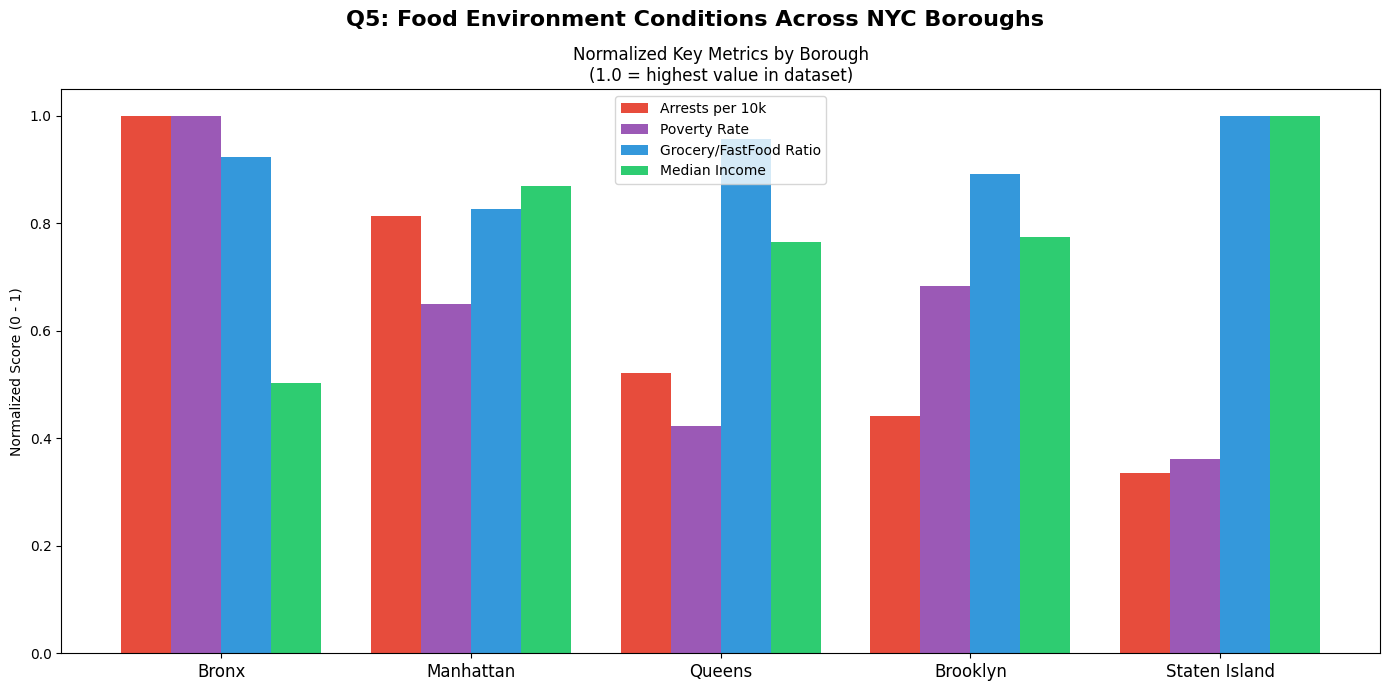

✅ Chart saved


In [8]:
# Q5 - Normalized Key Metrics by Borough
q5_sorted = q5_df.sort_values("avg_arrests_per_10k", ascending=False)
colors = [borough_colors[b] for b in q5_sorted["borough"]]

fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle("Q5: Food Environment Conditions Across NYC Boroughs",
             fontsize=16, fontweight="bold")

x = range(len(q5_sorted))
width = 0.2

ax.bar([i - width*1.5 for i in x], q5_sorted["avg_arrests_per_10k"] / q5_sorted["avg_arrests_per_10k"].max(),
       width, label="Arrests per 10k", color="#e74c3c")
ax.bar([i - width*0.5 for i in x], q5_sorted["avg_poverty_rate"] / q5_sorted["avg_poverty_rate"].max(),
       width, label="Poverty Rate", color="#9b59b6")
ax.bar([i + width*0.5 for i in x], q5_sorted["avg_grocery_ratio"] / q5_sorted["avg_grocery_ratio"].max(),
       width, label="Grocery/FastFood Ratio", color="#3498db")
ax.bar([i + width*1.5 for i in x], q5_sorted["avg_income"] / q5_sorted["avg_income"].max(),
       width, label="Median Income", color="#2ecc71")

ax.set_xticks(list(x))
ax.set_xticklabels(q5_sorted["borough"], fontsize=12)
ax.set_title("Normalized Key Metrics by Borough\n(1.0 = highest value in dataset)")
ax.set_ylabel("Normalized Score (0 - 1)")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("q5_borough_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")

---
### Interactive Map: Food Deserts & Crime Across NYC Neighborhoods

The map below plots each neighborhood studied, color coded by food desert 
classification. Circle size represents arrests per 10,000 residents — larger 
circles indicate higher crime rates. Clicking each marker reveals the 
neighborhood's key statistics.

In [10]:
import requests
import folium

# Fetch NYC ZIP code boundaries
r = requests.get("https://raw.githubusercontent.com/fedhere/PUI2015_EC/master/mam1612_EC/nyc-zip-code-tabulation-areas-polygons.geojson")
data = r.json()

# All ZIP codes
zip_to_neighborhood = {
    "10451": "South Bronx",
    "10454": "South Bronx",
    "10455": "South Bronx",
    "10452": "Highbridge",
    "10457": "Belmont",
    "10471": "Riverdale",
    "11207": "East New York",
    "11208": "East New York",
    "11221": "Bedford-Stuyvesant",
    "11233": "Bedford-Stuyvesant",
    "11213": "Crown Heights",
    "11205": "Clinton Hill / Fort Greene",
    "11201": "Clinton Hill / Fort Greene",
    "11231": "Red Hook",
    "11215": "Park Slope",
    "11217": "Park Slope",
    "11235": "Sheepshead Bay",
    "11224": "Coney Island",
    "11214": "Bensonhurst",
    "11230": "Midwood",
    "10032": "Washington Heights",
    "10033": "Washington Heights",
    "10037": "Harlem",
    "10039": "Harlem",
    "10023": "Upper West Side",
    "10024": "Upper West Side",
    "10003": "Greenwich Village",
    "10002": "Chinatown / Lower East Side",
    "11102": "Astoria",
    "11103": "Astoria",
    "11432": "Jamaica",
    "11433": "Jamaica",
    "11375": "Forest Hills",
    "11415": "Kew Gardens",
    "11379": "Middle Village",
    "11691": "Far Rockaway",
    "10301": "St. George",
    "10307": "Tottenville",
}

# Filter GeoJSON to our ZIP codes
filtered_features = [
    f for f in data["features"]
    if f["properties"]["postalCode"] in zip_to_neighborhood
]
print(f"✓ Matched {len(filtered_features)} ZIP code boundaries")

# Build neighborhood lookup
neighborhood_info = summary_df.set_index("neighborhood").to_dict(orient="index")

# Create map
m = folium.Map(location=[40.7308, -73.9352], zoom_start=11,
               tiles="CartoDB positron")

# Add ZIP boundaries
for feature in filtered_features:
    zip_code = feature["properties"]["postalCode"]
    neighborhood = zip_to_neighborhood.get(zip_code)
    if not neighborhood:
        continue

    info = neighborhood_info.get(neighborhood, {})
    is_desert = info.get("is_food_desert", False)
    fill_color = "#e74c3c" if is_desert else "#2ecc71"

    popup_html = f"""
    <div style="font-family: Arial; width: 240px;">
        <h4 style="margin-bottom:5px;">{neighborhood}</h4>
        <b>ZIP Code:</b> {zip_code}<br>
        <hr style="margin:4px 0">
        <b>Food Desert:</b> {"🏜️ Yes" if is_desert else "✅ No"}<br>
        <b>Borough:</b> {info.get('borough', 'N/A')}<br>
        <b>Population:</b> {int(info.get('total_population', 0)):,}<br>
        <b>Median Income:</b> ${int(info.get('avg_median_income', 0)):,}<br>
        <b>Poverty Rate:</b> {info.get('poverty_rate', 0)}%<br>
        <b>Grocery Stores:</b> {int(info.get('grocery store_count', 0))}<br>
        <b>Bodegas:</b> {int(info.get('bodega_count', 0))}<br>
        <b>Fast Food:</b> {int(info.get('fast food_count', 0))}<br>
        <b>Grocery/FastFood Ratio:</b> {info.get('grocery_to_fastfood_ratio', 0)}<br>
        <b>Avg Google Rating:</b> {info.get('avg_google_rating', 0):.2f}⭐<br>
        <b>Total Arrests:</b> {int(info.get('total_arrests', 0)):,}<br>
        <b>Arrests per 10k:</b> {info.get('arrests_per_10k', 0)}<br>
        <b>% Grade A Inspections:</b> {info.get('pct_grade_A', 0)}%
    </div>
    """

    folium.GeoJson(
        feature,
        style_function=lambda x, fc=fill_color: {
            "fillColor": fc,
            "color": "white",
            "weight": 2,
            "fillOpacity": 0.6
        },
        tooltip=f"{neighborhood} ({'🏜️ Food Desert' if is_desert else '✅ Non-Desert'}) — ZIP {zip_code}",
        popup=folium.Popup(popup_html, max_width=260)
    ).add_to(m)

# Legend
legend_html = """
<div style="position: fixed; bottom: 40px; left: 40px; z-index: 1000;
     background-color: white; padding: 12px; border-radius: 8px;
     border: 2px solid grey; font-family: Arial; font-size: 13px;">
    <b>NYC Food Desert Map</b><br><br>
    <span style="color:#e74c3c;">●</span> Food Desert<br>
    <span style="color:#2ecc71;">●</span> Non-Food Desert<br><br>
    <i>Click a neighborhood for details</i>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m.save("fooddesert_map.html")
m

✓ Matched 39 ZIP code boundaries


---
## Conclusions & Reflections

The data collected across 27 NYC neighborhoods strongly supports the central 
thesis: **food insecurity is a social determinant of crime.**

### Key Findings

**1. Food Deserts Are Widespread Across All Five Boroughs**
23 out of 27 neighborhoods studied qualify as food deserts based on having more 
fast food establishments than grocery stores per 10,000 residents. This is not 
an isolated problem confined to one borough.

**2. Food Deserts Have 1.3x More Arrests Per Capita**
After normalizing for population, food desert neighborhoods average 505.6 arrests 
per 10,000 residents compared to 392.5 in non-food desert neighborhoods. South 
Bronx stands as the starkest example at 1,379 arrests per 10,000 — more than 
11x the rate of Sheepshead Bay at 125, the lowest in the dataset.

**3. Income Is a Weak Predictor of Food Access**
The correlation between median income and grocery-to-fast-food ratio is only 0.02 
across 27 neighborhoods — essentially no relationship. Higher income does not 
reliably predict better grocery access at the neighborhood level in NYC. 
Neighborhood character, density, and history matter just as much as wealth.

**4. The Greenwich Village Anomaly**
Greenwich Village has a high median income yet is classified as a food desert 
with 1,163 arrests per 10,000 — one of the highest in the dataset. Its dense 
nightlife scene, large student population, tourism, and homeless concentration 
create a crime profile that defies the income-crime relationship seen elsewhere. 
This is not a data error — it is a feature of NYC's urban complexity.

**5. The Bronx Bears the Heaviest Burden**
The Bronx has the highest average arrest rate, the lowest median income, and the 
highest poverty rate of all five boroughs. South Bronx alone has a poverty rate 
of 35.5% and a grocery-to-fast-food ratio of 0.50 — fast food outlets outnumber 
grocery stores two to one per capita.

**6. Bodegas Don't Fill the Gap**
South Bronx has 32 bodegas compared to 26 grocery stores — confirming that 
convenience stores are substituting for proper supermarket access. While bodegas 
provide some food options they primarily stock processed goods rather than fresh 
produce, reinforcing food insecurity rather than solving it.

---

### Problems Encountered

The original plan was to use the **Yelp Fusion API** but Yelp had deprecated 
their free tier making it cost-prohibitive. The project pivoted to the Google 
Places API which provided sufficient free credit to cover all queries. Full 
data completeness cannot be verified since there is no ground truth dataset 
listing every food establishment in NYC — Google Places caps at 60 results per 
query, newer or informal establishments may not be listed, and bodegas are often 
miscategorized. A dedicated bodega search type was added to partially address this.

ZIP code tabulation areas were chosen as the geographic unit over neighborhood 
names or radius searches because they are officially defined boundaries that map 
directly to NYC Open Data crime and inspection datasets. A major challenge emerged 
when the NYPD arrests dataset was found to contain no ZIP code field — only 
latitude and longitude coordinates stored as strings. Geographic bounding boxes 
were defined for each ZIP code and the Socrata API query was rewritten to treat 
coordinates as strings rather than numeric values, which resolved the issue.

---

### Limitations
- Google Places data may underrepresent informal food establishments and 
  street vendors which are critical food sources in lower-income neighborhoods
- Neighborhood boundaries are approximated using ZIP codes — some ZIP codes 
  cover multiple distinct neighborhoods
- Only 27 of NYC's 300+ neighborhoods were studied 
- Correlation does not imply causation — food insecurity and crime likely share 
  common root causes in poverty and systemic inequality
- The NYPD arrests dataset reflects policing patterns as much as actual crime — 
  over-policed neighborhoods will show higher arrest counts regardless of 
  underlying crime rates

---

### Potential Future Work
- Expand to all NYC ZIP codes for a true city-wide analysis
- Incorporate MTA subway and bus access data to measure transit proximity 
  to grocery stores
- Add time-series analysis to track how food access and crime change over time
- Include street vendor and farmers market data from NYC business licensing
- Analyze fresh produce availability within establishments rather than just 
  establishment type

In [12]:
# Final Summary Table
print("=" * 80)
print("FINAL SUMMARY — NYC FOOD DESERT & CRIME ANALYSIS")
print("=" * 80)

final_df = summary_df[[
    "neighborhood",
    "borough",
    "total_population",
    "avg_median_income",
    "poverty_rate",
    "grocery_to_fastfood_ratio",
    "grocery_per_10k",
    "bodega_per_10k",
    "fastfood_per_10k",
    "arrests_per_10k",
    "avg_google_rating",
    "pct_grade_A",
    "is_food_desert"
]].copy()

final_df = final_df.sort_values("arrests_per_10k", ascending=False)

final_df.columns = [
    "Neighborhood", "Borough", "Population", "Median Income",
    "Poverty Rate (%)", "Grocery/FastFood Ratio",
    "Groceries per 10k", "Bodegas per 10k", "FastFood per 10k",
    "Arrests per 10k", "Avg Google Rating", "% Grade A", "Food Desert?"
]

final_df["Population"] = final_df["Population"].apply(lambda x: f"{x:,.0f}")
final_df["Median Income"] = final_df["Median Income"].apply(lambda x: f"${x:,.0f}")
final_df["Food Desert?"] = final_df["Food Desert?"].apply(lambda x: "🏜️ Yes" if x else "✅ No")

display(final_df)

print("\n📊 Key Statistics:")
print(f"  Total neighborhoods studied:          {len(summary_df)}")
print(f"  Food deserts identified:              {summary_df['is_food_desert'].sum()}")
print(f"  Non-food deserts:                     {(~summary_df['is_food_desert']).sum()}")
print(f"  Total food establishments collected:  {len(places_df):,}")
print(f"  Total arrests analyzed:               {len(arrests_df.drop_duplicates(subset='arrest_key')):,}")
print(f"  Total inspections analyzed:           {len(inspections_df):,}")
print(f"  Avg arrests per 10k — Food Deserts:   {summary_df[summary_df['is_food_desert']==True]['arrests_per_10k'].mean():.1f}")
print(f"  Avg arrests per 10k — Non-Deserts:    {summary_df[summary_df['is_food_desert']==False]['arrests_per_10k'].mean():.1f}")
print(f"  Highest arrest rate:                  {summary_df.loc[summary_df['arrests_per_10k'].idxmax(), 'neighborhood']} ({summary_df['arrests_per_10k'].max():.1f} per 10k)")
print(f"  Lowest arrest rate:                   {summary_df.loc[summary_df['arrests_per_10k'].idxmin(), 'neighborhood']} ({summary_df['arrests_per_10k'].min():.1f} per 10k)")
print(f"  Highest poverty rate:                 {summary_df.loc[summary_df['poverty_rate'].idxmax(), 'neighborhood']} ({summary_df['poverty_rate'].max():.1f}%)")
print(f"  Lowest grocery/fastfood ratio:        {summary_df.loc[summary_df['grocery_to_fastfood_ratio'].idxmin(), 'neighborhood']} ({summary_df['grocery_to_fastfood_ratio'].min():.2f})")
print(f"  Income correlation with ratio:        {summary_df['avg_median_income'].corr(summary_df['grocery_to_fastfood_ratio']):.2f}")
print(f"  Income correlation with crime:        {summary_df['avg_median_income'].corr(summary_df['arrests_per_10k']):.2f}")

FINAL SUMMARY — NYC FOOD DESERT & CRIME ANALYSIS


,Neighborhood,Borough,Population,Median Income,Poverty Rate (%),Grocery/FastFood Ratio,Groceries per 10k,Bodegas per 10k,FastFood per 10k,Arrests per 10k,Avg Google Rating,% Grade A,Food Desert?
22,South Bronx,Bronx,"132,283","$33,771",35.5,0.50,1.97,2.42,3.93,1378.6,4.189610,94.7,🏜️ Yes
11,Greenwich Village,Manhattan,"53,825","$153,750",10.4,0.80,2.97,1.86,3.72,1163.0,4.300000,94.4,🏜️ Yes
4,Chinatown / Lower East Side,Manhattan,"75,517","$46,525",24.6,0.85,2.25,2.65,2.65,1120.5,4.231579,90.0,🏜️ Yes
13,Highbridge,Bronx,"76,745","$37,854",34.9,0.89,2.08,2.08,2.35,992.6,4.256923,88.4,🏜️ Yes
1,Bedford-Stuyvesant,Brooklyn,"173,461","$73,578",22.6,0.57,1.04,0.86,1.84,732.7,4.303125,89.8,🏜️ Yes
15,Kew Gardens,Queens,"21,379","$88,632",9.3,0.90,8.42,7.48,9.35,660.9,4.208824,93.8,🏜️ Yes
14,Jamaica,Queens,"101,507","$73,286",13.9,0.94,2.96,1.48,3.15,553.2,4.228037,93.9,🏜️ Yes
26,Washington Heights,Manhattan,"109,190","$66,086",18.2,0.70,2.11,2.29,3.02,540.6,4.216667,93.0,🏜️ Yes
6,Coney Island,Brooklyn,"48,469","$41,449",27.6,0.95,3.92,0.62,4.13,472.5,4.142105,93.7,🏜️ Yes
8,East New York,Brooklyn,"200,346","$57,704",23.2,0.92,1.70,1.45,1.85,443.1,4.142963,94.7,🏜️ Yes



📊 Key Statistics:
  Total neighborhoods studied:          27
  Food deserts identified:              23
  Non-food deserts:                     4
  Total food establishments collected:  2,315
  Total arrests analyzed:               111,636
  Total inspections analyzed:           65,959
  Avg arrests per 10k — Food Deserts:   505.6
  Avg arrests per 10k — Non-Deserts:    392.5
  Highest arrest rate:                  South Bronx (1378.6 per 10k)
  Lowest arrest rate:                   Sheepshead Bay (125.4 per 10k)
  Highest poverty rate:                 South Bronx (35.5%)
  Lowest grocery/fastfood ratio:        South Bronx (0.50)
  Income correlation with ratio:        0.02
  Income correlation with crime:        -0.24
